Import Packages + Read Dataset

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import seaborn as sns
import numpy as np
import pyproj

In [3]:
df = pd.read_pickle('../data/df4_with_regions.pkl')

Singapore's Geographic Range
- Latitude Range: ~1.129N to ~1.493N
- Longitude Range: ~103.557E to ~104.07E

In [6]:
print(df[['ORIG_LATITUDE','ORIG_LONGITUDE']].describe())

       ORIG_LATITUDE  ORIG_LONGITUDE
count   7.679059e+06    7.679059e+06
mean    1.348678e+00    1.038372e+02
std     4.681278e-02    6.861787e-02
min     1.251427e+00    1.036172e+02
25%     1.312519e+00    1.037859e+02
50%     1.342060e+00    1.038442e+02
75%     1.378218e+00    1.038869e+02
max     1.493904e+00    1.040300e+02


In [ ]:
# drop rows with 0 or NaN in coordinates
df_clean = df.dropna(subset=['ORIG_LATITUDE','ORIG_LONGITUDE',
                            'DEST_LATITUDE','DEST_LONGITUDE'])
df_clean = df_clean[(df_clean['ORIG_LATITUDE'] > 0) & (df_clean['ORIG_LONGITUDE'] > 0)]
df_clean = df_clean[(df_clean['DEST_LATITUDE'] > 0) & (df_clean['DEST_LONGITUDE'] > 0)]

# check that they are in the correct ranges for Singapore
print(df_clean[['ORIG_LONGITUDE','ORIG_LATITUDE','DEST_LONGITUDE','DEST_LATITUDE']].describe())

       ORIG_LONGITUDE  ORIG_LATITUDE  DEST_LONGITUDE  DEST_LATITUDE
count    7.650050e+06   7.650050e+06    7.650050e+06   7.650050e+06
mean     1.038372e+02   1.348665e+00    1.038350e+02   1.348711e+00
std      6.860647e-02   4.681898e-02    6.934134e-02   4.606907e-02
min      1.036172e+02   1.251427e+00    1.036172e+02   1.251427e+00
25%      1.037859e+02   1.312519e+00    1.037818e+02   1.313993e+00
50%      1.038442e+02   1.342044e+00    1.038438e+02   1.342682e+00
75%      1.038867e+02   1.378218e+00    1.038855e+02   1.376890e+00
max      1.040300e+02   1.493904e+00    1.040300e+02   1.493904e+00


In [9]:
print("Total tap-ins:", len(df_clean))
print("Total tap-outs:", len(df_clean))

Total tap-ins: 7650050
Total tap-outs: 7650050


Plot Hexbin Density Map

In [11]:
# convert to GeoDataFrame in Web Mercator 
gdf_orig = gpd.GeoDataFrame(
    df_clean,
    geometry=gpd.points_from_xy(df_clean['ORIG_LONGITUDE'], df_clean['ORIG_LATITUDE']),
    crs='EPSG:4326'
).to_crs(epsg=3857)

gdf_dest = gpd.GeoDataFrame(
    df_clean,
    geometry=gpd.points_from_xy(df_clean['DEST_LONGITUDE'], df_clean['DEST_LATITUDE']),
    crs='EPSG:4326'
).to_crs(epsg=3857)

In [12]:
# setting the map boundaries in the Web Mercator projection for Singapore
proj = pyproj.Transformer.from_crs("epsg:4326","epsg:3857",always_xy=True)
xmin, ymin = proj.transform(103.6, 1.2)
xmax, ymax = proj.transform(104.0, 1.5)

In [14]:
# For origin points
x_orig = gdf_orig.geometry.x
y_orig = gdf_orig.geometry.y

# For destination points
x_dest = gdf_dest.geometry.x
y_dest = gdf_dest.geometry.y

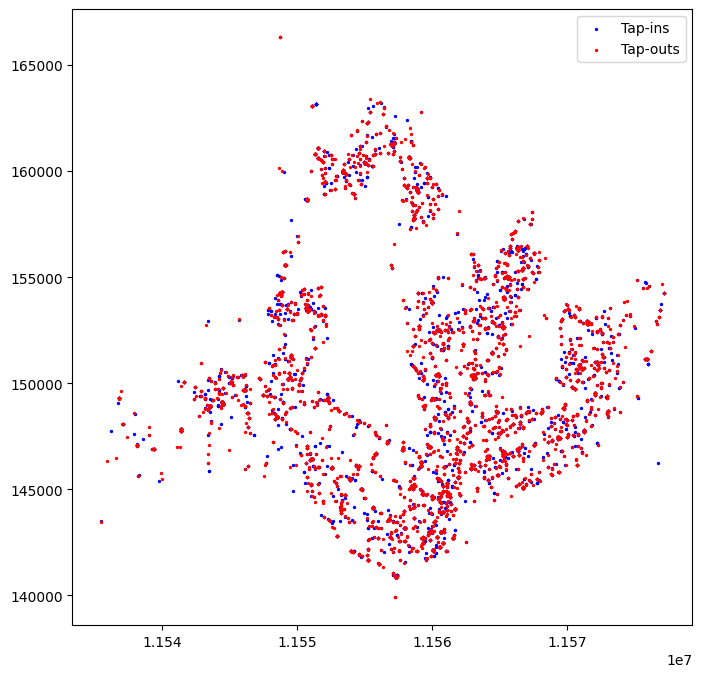

In [15]:
#scatter plot of tap-ins and tap-outs
plt.figure(figsize=(8,8))
plt.scatter(x_orig[:5000], y_orig[:5000], color='blue', s=2, label='Tap-ins')
plt.scatter(x_dest[:5000], y_dest[:5000], color='red', s=2, label='Tap-outs')
plt.legend()
plt.show()

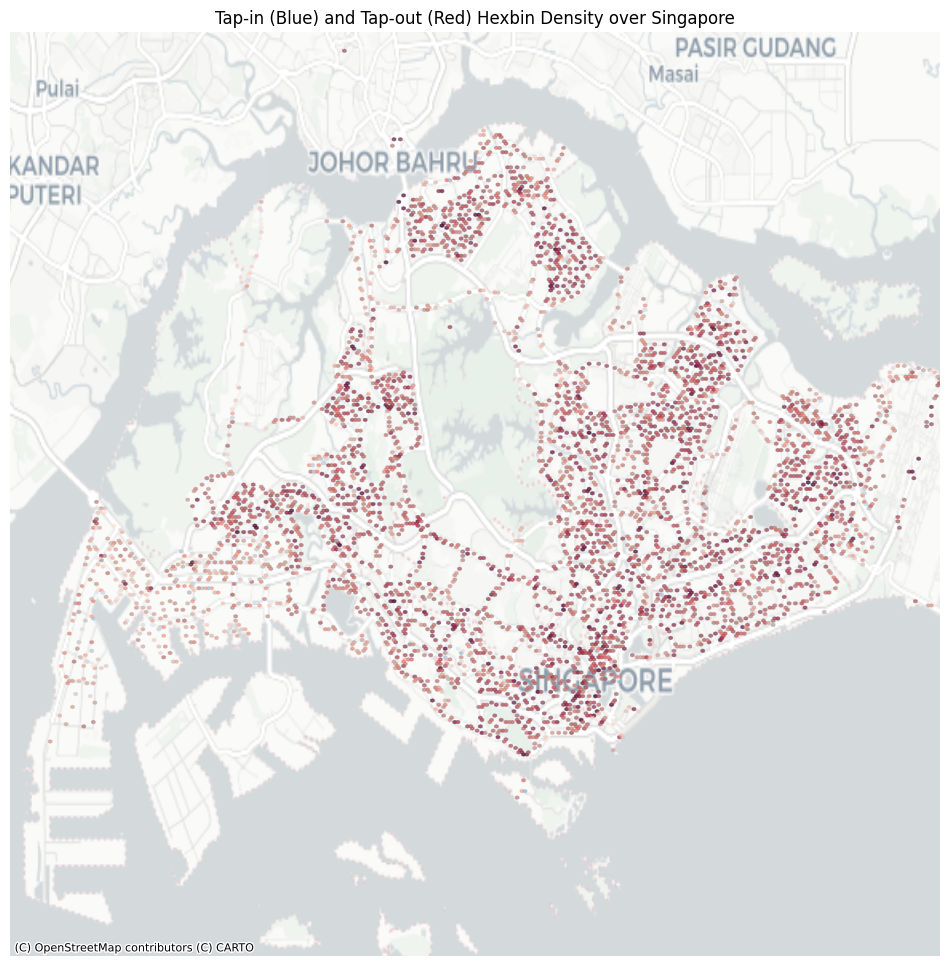

In [16]:
#plot hexbin density map
fig, ax = plt.subplots(figsize=(12,12))

# hexbin for origins (blue)
ax.hexbin(
    gdf_orig.geometry.x, gdf_orig.geometry.y, 
    gridsize=300, cmap='Blues', alpha=0.6, bins='log'
)

# hexbin for destinations (red)
ax.hexbin(
    gdf_dest.geometry.x, gdf_dest.geometry.y, 
    gridsize=300, cmap='Reds', alpha=0.4, bins='log'
)

# set visible area over sg
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)


ax.set_axis_off()
plt.title("Tap-in (Blue) and Tap-out (Red) Hexbin Density over Singapore")
plt.show()

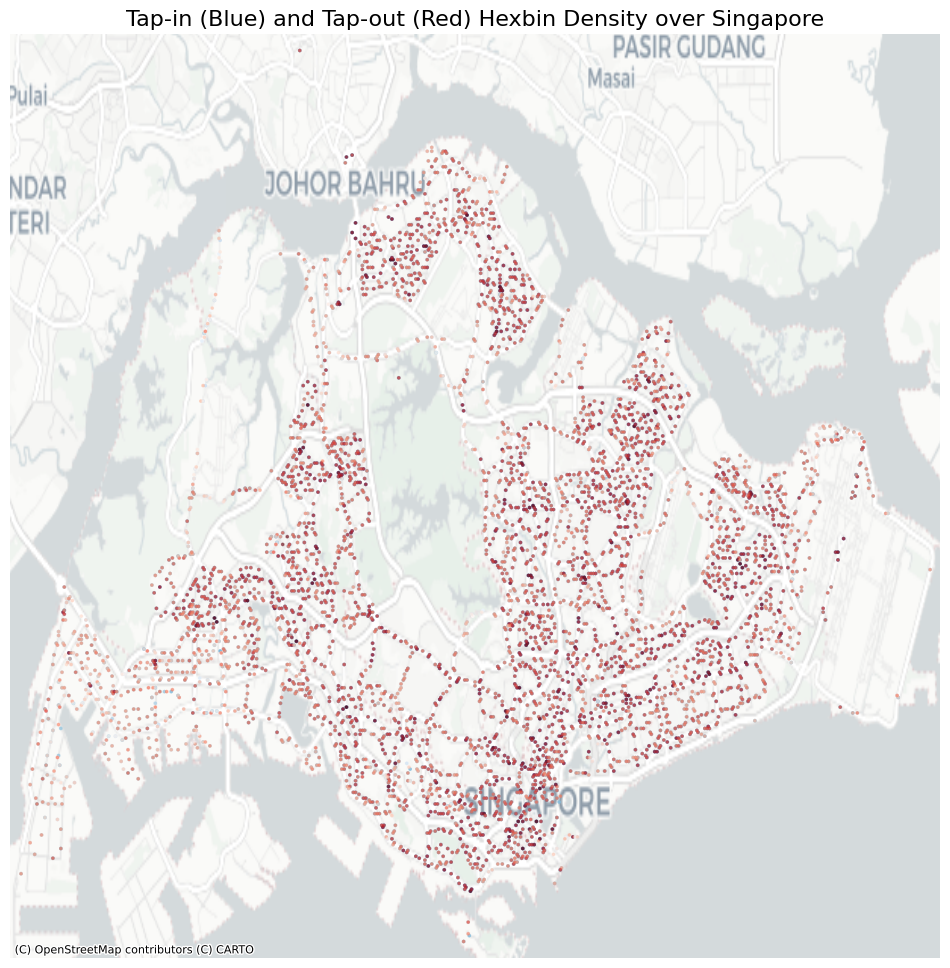

In [17]:
#rescale hexbin to capture more dispersed tap-ins/tap-outs across Singapore

# set finer hexbin resolution
hex_gridsize = 400  # smaller hexes to capture dispersed tap-ins

fig, ax = plt.subplots(figsize=(12,12))

# origins(blue): tap-ins
hb_orig = ax.hexbin(
    gdf_orig.geometry.x, gdf_orig.geometry.y,
    gridsize=hex_gridsize, cmap='Blues',
    alpha=0.7, bins='log'
)

# destinations(red):tap-outs
hb_dest = ax.hexbin(
    gdf_dest.geometry.x, gdf_dest.geometry.y,
    gridsize=hex_gridsize, cmap='Reds',
    alpha=0.5, bins='log'
)

# set singapore extent based on data
ax.set_xlim(gdf_orig.geometry.x.min()-500, gdf_orig.geometry.x.max()+500)
ax.set_ylim(gdf_orig.geometry.y.min()-500, gdf_orig.geometry.y.max()+500)

# add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# remove axis 
ax.set_axis_off()
plt.title("Tap-in (Blue) and Tap-out (Red) Hexbin Density over Singapore", fontsize=16)
plt.show()

In [18]:
# Count points per hex manually for origins to verify hexbin counts
x = gdf_orig.geometry.x.values
y = gdf_orig.geometry.y.values
counts, xedges, yedges = np.histogram2d(x, y, bins=400)  # same gridsize as hexbin

print("Max tap-ins per hex:", counts.max())
print("Mean tap-ins per hex:", counts.mean())

Max tap-ins per hex: 82421.0
Mean tap-ins per hex: 47.8128125


In [19]:
# Count points per hex manually for destinations
x = gdf_dest.geometry.x.values
y = gdf_dest.geometry.y.values
counts, xedges, yedges = np.histogram2d(x, y, bins=400)  # same gridsize as hexbin

print("Max tap-outs per hex:", counts.max())
print("Mean tap-outs per hex:", counts.mean())

Max tap-outs per hex: 91352.0
Mean tap-outs per hex: 47.8128125


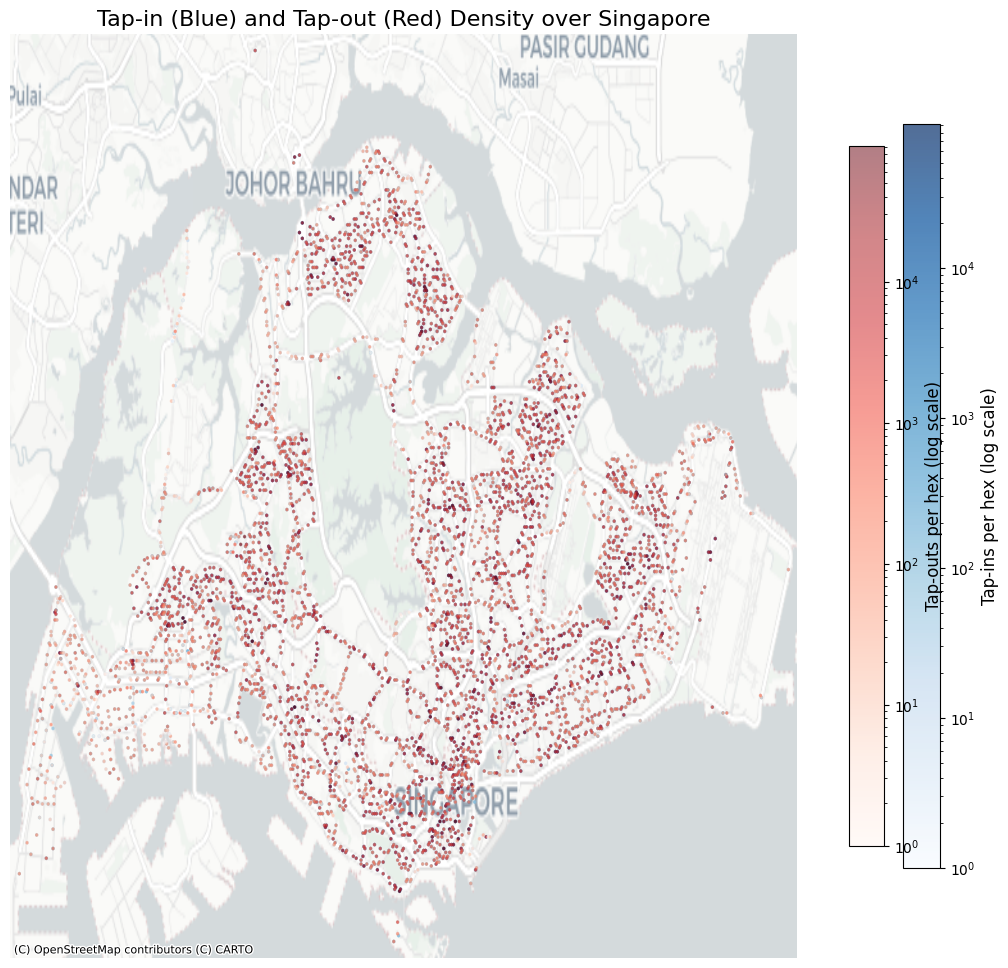

In [20]:
# differences from previous map:
# histogram2d helps to find the maximum count across hexes,
# so both tap-in (blue) and tap-out (red) layers share the same color scale
# includes colorbars

# extract coordinates
x_orig = gdf_orig.geometry.x.values
y_orig = gdf_orig.geometry.y.values
x_dest = gdf_dest.geometry.x.values
y_dest = gdf_dest.geometry.y.values

# use histogram2d to find maximum per hex (for consistent color scaling)
counts_orig, _, _ = np.histogram2d(x_orig, y_orig, bins=400)
counts_dest, _, _ = np.histogram2d(x_dest, y_dest, bins=400)
max_count = int(max(counts_orig.max(), counts_dest.max()))


fig, ax = plt.subplots(figsize=(12,12))

# blues are tap-ins
hb_orig = ax.hexbin(
    x_orig, y_orig,
    gridsize=400,
    bins='log',  # log scale to show sparse areas
    cmap='Blues',
    alpha=0.7,
    vmin=1, vmax=max_count
)

# red are tap-outs
hb_dest = ax.hexbin(
    x_dest, y_dest,
    gridsize=400,
    bins='log',
    cmap='Reds',
    alpha=0.5,
    vmin=1, vmax=max_count
)

#zoom to singapore context
margin = 500  # meters
ax.set_xlim(x_orig.min()-margin, x_orig.max()+margin)
ax.set_ylim(y_orig.min()-margin, y_orig.max()+margin)

# add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# add color bars
cbar_orig = fig.colorbar(hb_orig, ax=ax, fraction=0.04, pad=0.02)
cbar_orig.set_label("Tap-ins per hex (log scale)", fontsize=12)
cbar_dest = fig.colorbar(hb_dest, ax=ax, fraction=0.04, pad=0.06)
cbar_dest.set_label("Tap-outs per hex (log scale)", fontsize=12)

ax.set_axis_off()
plt.title("Tap-in (Blue) and Tap-out (Red) Density over Singapore", fontsize=16)
plt.show()